# Орбитальное движение в 2D: Эйлер vs RK4, сохранение интегралов, аналитическая эллиптическая орбита

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Для воспроизводимости графиков (если добавите шум/рандомизацию)
np.random.seed(0)

## 1. Математическая модель (2D задача Кеплера)

Пусть центральное тело имеет гравитационный параметр $\mu = GM$.
Состояние частицы в плоскости:
$$\mathbf{y} = (x,\,y,\,v_x,\,v_y)^T.$$
Уравнения движения:
$$\dot{x}=v_x,\qquad \dot{y}=v_y,$$
$$\dot{\mathbf{v}} = -\mu\,\frac{\mathbf{r}}{r^3},\qquad \mathbf{r}=(x,y),\ r=\|\mathbf{r}\|.$$

Интегралы движения (для точного решения):
- **Полная удельная энергия**
$$\varepsilon = \frac12\|\mathbf{v}\|^2 - \frac{\mu}{r}.$$
- **Удельный угловой момент** (скаляр в 2D)
$$h = (\mathbf{r}\times\mathbf{v})_z = x v_y - y v_x.$$

Для эллиптической орбиты $\varepsilon < 0$, а период $T = 2\pi\sqrt{a^3/\mu}$, где $a$ — большая полуось.

## 2. Численные методы: Эйлер и RK4

Пишем задачу как $\dot{\mathbf{y}}=\mathbf{f}(\mathbf{y})$.

**Явный Эйлер**:
$$\mathbf{y}_{n+1}=\mathbf{y}_n + \Delta t\,\mathbf{f}(\mathbf{y}_n).$$
Метод 1-го порядка: ошибка на шаг $O(\Delta t^2)$, глобальная $O(\Delta t)$.

**Классический RK4**:
$$\begin{aligned}
k_1&=f(y_n),\\
k_2&=f(y_n+\tfrac{\Delta t}{2}k_1),\\
k_3&=f(y_n+\tfrac{\Delta t}{2}k_2),\\
k_4&=f(y_n+\Delta t\,k_3),\\
y_{n+1}&=y_n+\tfrac{\Delta t}{6}(k_1+2k_2+2k_3+k_4).
\end{aligned}$$
Метод 4-го порядка: глобальная ошибка $O(\Delta t^4)$.

In [2]:

def kepler_rhs(state, mu):
    """Правая часть для 2D задачи Кеплера.
    state: (...,4) -> [x,y,vx,vy]
    """
    x, y, vx, vy = state
    r2 = x*x + y*y
    r = np.sqrt(r2)
    ax = -mu * x / (r*r2)
    ay = -mu * y / (r*r2)
    return np.array([vx, vy, ax, ay], dtype=float)

def step_euler(state, dt, mu):
    return state + dt * kepler_rhs(state, mu)

def step_rk4(state, dt, mu):
    k1 = kepler_rhs(state, mu)
    k2 = kepler_rhs(state + 0.5*dt*k1, mu)
    k3 = kepler_rhs(state + 0.5*dt*k2, mu)
    k4 = kepler_rhs(state + dt*k3, mu)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def integrate_orbit(state0, t, mu, method="rk4"):
    """Интегрирует траекторию по сетке времени t (1D array)."""
    y = np.zeros((len(t), 4), dtype=float)
    y[0] = state0
    dt = t[1] - t[0]
    step = step_rk4 if method.lower() == "rk4" else step_euler
    for i in range(len(t)-1):
        y[i+1] = step(y[i], dt, mu)
    return y

def energy_and_h(y, mu):
    x, yy, vx, vy = y[:,0], y[:,1], y[:,2], y[:,3]
    r = np.sqrt(x*x + yy*yy)
    v2 = vx*vx + vy*vy
    eps = 0.5*v2 - mu/r
    h = x*vy - yy*vx
    return eps, h


## 3. Аналитическая эллиптическая орбита через элементы орбиты и уравнение Кеплера

Для эллипса:
- $a = -\mu/(2\varepsilon)$
- $\mathbf{h} = \mathbf{r}\times\mathbf{v}$
- **вектор эксцентриситета**
$$\mathbf{e} = \frac{\mathbf{v}\times\mathbf{h}}{\mu} - \frac{\mathbf{r}}{r},\qquad e=\|\mathbf{e}\|.$$

Дальше используем параметризацию через эксцентрическую аномалию $E$:
$$M(t)=M_0+n t,\quad n=\sqrt{\mu/a^3},$$
$$M=E-e\sin E\ \Rightarrow\ \text{находим }E \text{ методом Ньютона}.$$

Положение в базисе $(\hat{p},\hat{q})$ (в плоскости орбиты), где $\hat{p}$ направлен вдоль $\mathbf{e}$:
$$\mathbf{r}(t)=a(\cos E - e)\,\hat{p} + a\sqrt{1-e^2}\sin E\,\hat{q}.$$

In [3]:

def orbital_elements_from_state(r, v, mu):
    """Элементы орбиты для плоского случая (векторная форма).
    Возвращает a, e, h (скаляр), e_vec, p_hat, q_hat, M0, n.
    """
    r = np.asarray(r, dtype=float)
    v = np.asarray(v, dtype=float)
    R = np.linalg.norm(r)
    V2 = float(np.dot(v, v))
    eps = 0.5*V2 - mu/R
    a = -mu/(2*eps)  # для эллипса eps<0

    # Угловой момент (скаляр z-компонента)
    h = r[0]*v[1] - r[1]*v[0]

    # Вектор эксцентриситета: e = (v x h)/mu - r/r
    # В 2D: v x h_z -> (h*vy, -h*vx)
    e_vec = np.array([h*v[1]/mu - r[0]/R, -h*v[0]/mu - r[1]/R], dtype=float)
    e = float(np.linalg.norm(e_vec))

    # Перицентрический базис
    if e > 1e-14:
        p_hat = e_vec / e
    else:
        # почти круговая: выбираем p_hat вдоль r
        p_hat = r / R
    q_hat = np.array([-p_hat[1], p_hat[0]], dtype=float)  # поворот на +90°

    # Найдём E0 и M0 из геометрии: r = a(cosE-e)p + a*sqrt(1-e^2) sinE q
    # Скалярные проекции:
    rp = float(np.dot(r, p_hat))
    rq = float(np.dot(r, q_hat))
    cosE = (rp/a) + e
    sinE = rq/(a*np.sqrt(max(1e-16, 1-e*e)))
    # численная стабилизация:
    cosE = np.clip(cosE, -1.0, 1.0)
    E0 = np.arctan2(sinE, cosE)
    M0 = E0 - e*np.sin(E0)

    n = np.sqrt(mu/(a*a*a))
    return a, e, h, e_vec, p_hat, q_hat, M0, n

def solve_kepler_E(M, e, tol=1e-12, max_iter=50):
    """Решает E - e sinE = M для эллипса (0<=e<1) методом Ньютона.
    M может быть массивом.
    """
    M = np.asarray(M, dtype=float)
    # хорошее начальное приближение:
    E = M.copy()
    if np.isscalar(e):
        ee = float(e)
        if ee > 0.8:
            E = np.pi*np.ones_like(M)
    else:
        raise ValueError("e должен быть скаляром")
    for _ in range(max_iter):
        f = E - ee*np.sin(E) - M
        fp = 1 - ee*np.cos(E)
        dE = -f/fp
        E = E + dE
        if np.max(np.abs(dE)) < tol:
            break
    return E

def analytic_orbit_positions(t, state0, mu):
    """Аналитическая траектория для эллиптической орбиты, заданной начальным состоянием."""
    r0 = state0[:2]
    v0 = state0[2:]
    a, e, h, e_vec, p_hat, q_hat, M0, n = orbital_elements_from_state(r0, v0, mu)
    M = M0 + n*t
    # нормируем M в [-pi, pi] для численной устойчивости Ньютона
    M = (M + np.pi) % (2*np.pi) - np.pi
    E = solve_kepler_E(M, e)
    cosE = np.cos(E)
    sinE = np.sin(E)
    fac = np.sqrt(max(1e-16, 1-e*e))
    r = (a*(cosE - e))[:,None]*p_hat[None,:] + (a*fac*sinE)[:,None]*q_hat[None,:]
    return r, dict(a=a, e=e, h=h)


## 4. Сравнение численного решения с аналитическим: энергия, момент, форма орбиты

Берём нормированные единицы: $\mu=1$, орбита с заданным эксцентриситетом $e$ и полуосью $a=1$.
Удобно стартовать из перицентра:
$$r_p=a(1-e),\quad v_p=\sqrt{\mu\frac{1+e}{a(1-e)}}.$$

In [4]:

def initial_state_from_ae(a, e, mu):
    """Старт из перицентра: r=(rp,0), v=(0,vp)."""
    rp = a*(1-e)
    vp = np.sqrt(mu*(1+e)/(a*(1-e)))
    return np.array([rp, 0.0, 0.0, vp], dtype=float)

mu = 1.0
a0 = 1.0
e0 = 0.4
state0 = initial_state_from_ae(a0, e0, mu)

# период по аналитике:
T = 2*np.pi*np.sqrt(a0**3/mu)
T


np.float64(6.283185307179586)

In [5]:

# Настройка расчёта
n_periods = 20
dt = 1e-3  # попробуйте 5e-3 / 1e-3 / 5e-4
t = np.arange(0.0, n_periods*T + dt, dt)

y_euler = integrate_orbit(state0, t, mu, method="euler")
y_rk4   = integrate_orbit(state0, t, mu, method="rk4")

eps_e, h_e = energy_and_h(y_euler, mu)
eps_r, h_r = energy_and_h(y_rk4, mu)

r_an, el = analytic_orbit_positions(t, state0, mu)

print("Analytic elements:", el)
print("Euler  : Δeps ~", float(eps_e[-1]-eps_e[0]), "  Δh ~", float(h_e[-1]-h_e[0]))
print("RK4    : Δeps ~", float(eps_r[-1]-eps_r[0]), "  Δh ~", float(h_r[-1]-h_r[0]))


Analytic elements: {'a': np.float64(1.0), 'e': 0.40000000000000013, 'h': np.float64(0.916515138991168)}
Euler  : Δeps ~ 0.12589691452308843   Δh ~ 0.10424310827749739
RK4    : Δeps ~ -7.127631818093505e-14   Δh ~ -3.141931159689193e-14


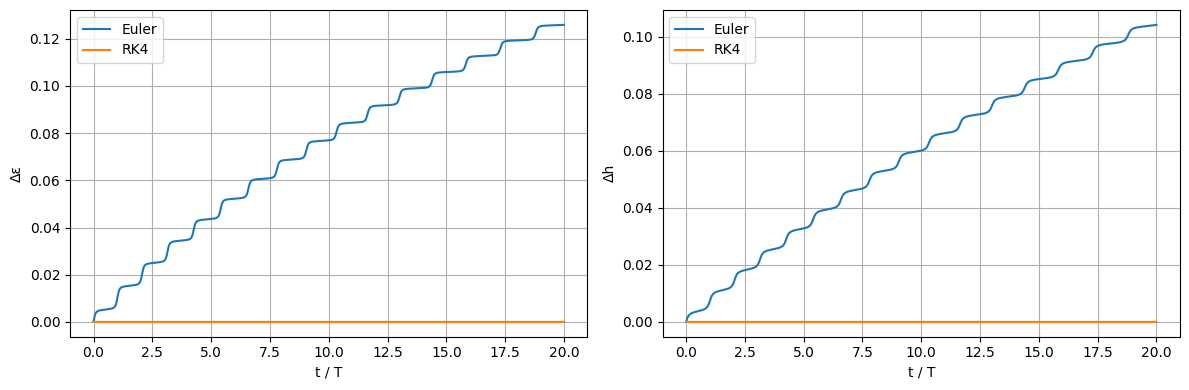

In [6]:

# Графики энергии и углового момента (отклонения от начальных)
fig = plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t/T, eps_e - eps_e[0], label="Euler")
plt.plot(t/T, eps_r - eps_r[0], label="RK4")
plt.xlabel("t / T")
plt.ylabel("Δε")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(t/T, h_e - h_e[0], label="Euler")
plt.plot(t/T, h_r - h_r[0], label="RK4")
plt.xlabel("t / T")
plt.ylabel("Δh")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


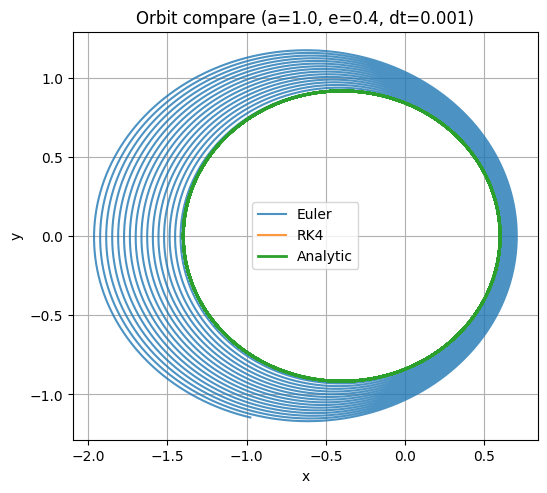

In [7]:

# Сравнение траекторий с аналитикой
fig = plt.figure(figsize=(6,6))
plt.plot(y_euler[:,0], y_euler[:,1], label="Euler", alpha=0.8)
plt.plot(y_rk4[:,0], y_rk4[:,1], label="RK4", alpha=0.8)
plt.plot(r_an[:,0], r_an[:,1], label="Analytic", linewidth=2)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.title(f"Orbit compare (a={a0}, e={e0}, dt={dt})")
plt.show()


## 5. Оценка накопления ошибки формы орбиты

Простая метрика: сравним радиус $r(t)$ численного решения с аналитическим $r_{an}(t)$ на одной и той же сетке времени:
$$\delta r(t)=r_{num}(t)-r_{an}(t).$$
Также полезно смотреть ошибку после целого числа периодов: $\|\mathbf{r}(kT)-\mathbf{r}_{an}(kT)\|$.

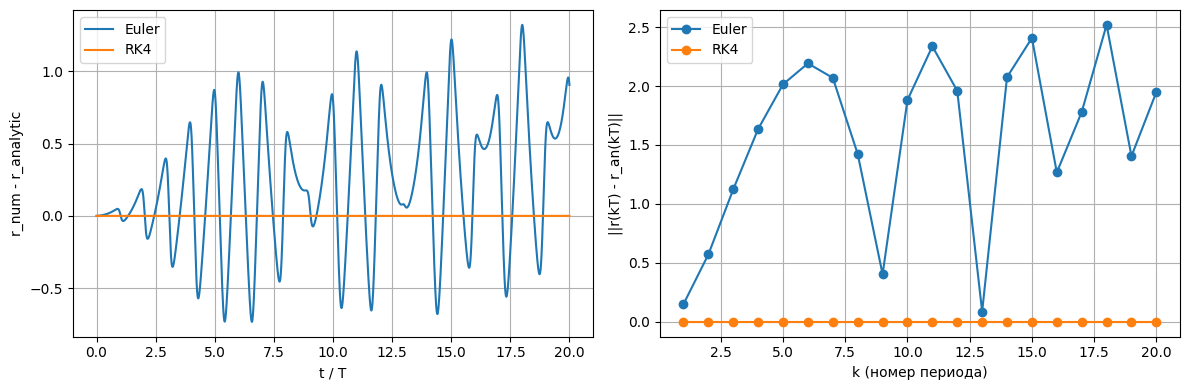

In [8]:

def radial_error(y_num, r_an):
    r_num = np.linalg.norm(y_num[:,:2], axis=1)
    r_ref = np.linalg.norm(r_an, axis=1)
    return r_num - r_ref

dr_e = radial_error(y_euler, r_an)
dr_r = radial_error(y_rk4, r_an)

# ошибка положения в моменты, близкие к целым периодам
k = np.arange(1, n_periods+1)
idx = np.round(k*T/dt).astype(int)
pos_err_e = np.linalg.norm(y_euler[idx,:2] - r_an[idx], axis=1)
pos_err_r = np.linalg.norm(y_rk4[idx,:2]   - r_an[idx], axis=1)

fig = plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t/T, dr_e, label="Euler")
plt.plot(t/T, dr_r, label="RK4")
plt.xlabel("t / T")
plt.ylabel("r_num - r_analytic")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(k, pos_err_e, "o-", label="Euler")
plt.plot(k, pos_err_r, "o-", label="RK4")
plt.xlabel("k (номер периода)")
plt.ylabel("||r(kT) - r_an(kT)||")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 6. Орбиты для разных эксцентриситетов

Держим $a=1$, меняем $e$. Для каждого случая стартуем из перицентра и интегрируем несколько периодов. Для корректного сравнения форм — достаточно одного периода, но для демонстрации устойчивости можно больше.

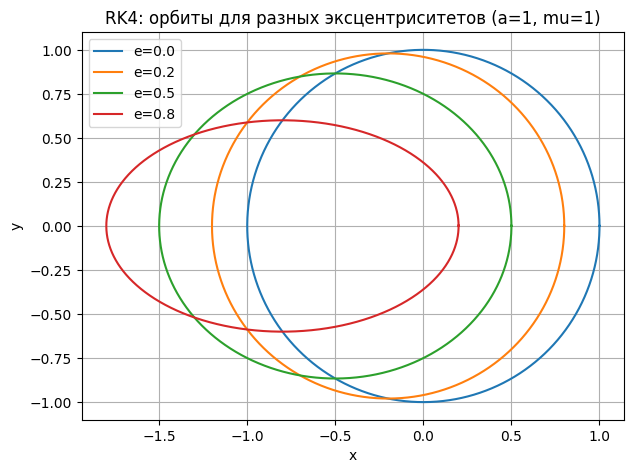

In [9]:

ecc_list = [0.0, 0.2, 0.5, 0.8]
dt_vis = 1e-3
fig = plt.figure(figsize=(7,7))

for e in ecc_list:
    state = initial_state_from_ae(a0, e, mu)
    T_e = 2*np.pi*np.sqrt(a0**3/mu)
    t_loc = np.arange(0, 1.0*T_e + dt_vis, dt_vis)
    y = integrate_orbit(state, t_loc, mu, method="rk4")
    plt.plot(y[:,0], y[:,1], label=f"e={e}")

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.title("RK4: орбиты для разных эксцентриситетов (a=1, mu=1)")
plt.show()


## 7. N-тельная модель: Солнце–Земля–Марс–Юпитер

Смоделируем движение нескольких тел в одной плоскости.

Используем единицы: **AU**, **год**, **масса Солнца**. Тогда
$$G = 4\pi^2\ \text{AU}^3/(\text{год}^2\,M_\odot).$$

Уравнения для $N$ тел:
$$\dot{\mathbf{r}}_i=\mathbf{v}_i,$$
$$\dot{\mathbf{v}}_i = -G\sum_{j\ne i} m_j\,\frac{\mathbf{r}_i-\mathbf{r}_j}{\|\mathbf{r}_i-\mathbf{r}_j\|^3}.$$

Инициализация упрощённая: почти круговые орбиты вокруг Солнца в одной плоскости (без наклонений), полуоси близки к реальным: Земля 1 AU, Марс 1.524 AU, Юпитер 5.204 AU. Задача: сравнить траектории Земли и Марса **с Юпитером** и **без Юпитера** и оценить разницу.

In [14]:

# Константы и массы (в единицах Msun)
G = 4*np.pi**2  # AU^3 / (yr^2 * Msun)

m_sun = 1.0
m_earth = 3.003e-6
m_mars  = 3.213e-7
m_jup   = 9.543e-4  # ~0.0009543

def nbody_acc(positions, masses, G=G, softening=0.0):
    """Ускорения для N тел.
    positions: (N,2)
    masses: (N,)
    """
    N = positions.shape[0]
    acc = np.zeros_like(positions, dtype=float)
    for i in range(N):
        ri = positions[i]
        ai = np.zeros(2, dtype=float)
        for j in range(N):
            if i == j: 
                continue
            rj = positions[j]
            dr = ri - rj
            dist2 = dr[0]*dr[0] + dr[1]*dr[1] + softening*softening
            dist = np.sqrt(dist2)
            ai += -G*masses[j] * dr / (dist*dist2)
        acc[i] = ai
    return acc

def nbody_rhs(state, masses, G=G):
    """state: (N,4) -> [x,y,vx,vy]"""
    pos = state[:,0:2]
    vel = state[:,2:4]
    acc = nbody_acc(pos, masses, G=G)
    out = np.zeros_like(state, dtype=float)
    out[:,0:2] = vel
    out[:,2:4] = acc
    return out

def nbody_step_rk4(state, dt, masses, G=G):
    k1 = nbody_rhs(state, masses, G)
    k2 = nbody_rhs(state + 0.5*dt*k1, masses, G)
    k3 = nbody_rhs(state + 0.5*dt*k2, masses, G)
    k4 = nbody_rhs(state + dt*k3, masses, G)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def integrate_nbody(state0, t, masses, G=G):
    y = np.zeros((len(t), state0.shape[0], 4), dtype=float)
    y[0] = state0
    dt = t[1] - t[0]
    for i in range(len(t)-1):
        y[i+1] = nbody_step_rk4(y[i], dt, masses, G)
    return y

def circular_orbit_state(a, m_central, phase=0.0, G=G):
    """Почти круговая орбита радиуса a вокруг центральной массы m_central, в плоскости.
    phase задаёт угол положения.
    """
    x = a*np.cos(phase); y = a*np.sin(phase)
    v = np.sqrt(G*m_central/a)
    # скорость перпендикулярна радиусу (против часовой)
    vx = -v*np.sin(phase); vy = v*np.cos(phase)
    return np.array([x,y,vx,vy], dtype=float)


In [15]:

# Сборка начальных условий (простая модель: все стартуют на разных фазах)
phase_earth = 0.0
phase_mars  = 1.0
phase_jup   = 2.0

a_earth = 1.0
a_mars  = 1.524
a_jup   = 5.204

# Солнце начально в начале координат.
sun_state = np.array([0.0, 0.0, 0.0, 0.0])

earth_state = circular_orbit_state(a_earth, m_sun, phase_earth)
mars_state  = circular_orbit_state(a_mars,  m_sun, phase_mars)
jup_state   = circular_orbit_state(a_jup,   m_sun, phase_jup)

# Чтобы система не улетала из-за ненулевого суммарного импульса, сдвинем скорость Солнца
def set_barycentric_velocities(states, masses):
    total_p = np.sum(states[:,2:4] * masses[:,None], axis=0)
    states[0,2:4] = -total_p / masses[0]
    return states

# С Юпитером
masses_J = np.array([m_sun, m_earth, m_mars, m_jup], dtype=float)
state0_J = np.vstack([sun_state, earth_state, mars_state, jup_state])
state0_J = set_barycentric_velocities(state0_J.copy(), masses_J)

# Без Юпитера
masses_noJ = np.array([m_sun, m_earth, m_mars], dtype=float)
state0_noJ = np.vstack([sun_state, earth_state, mars_state])
state0_noJ = set_barycentric_velocities(state0_noJ.copy(), masses_noJ)

# Время моделирования
years = 30
dt_year = 1/365.25  # 1 день в годах
tN = np.arange(0.0, years + dt_year, dt_year)

yJ   = integrate_nbody(state0_J,   tN, masses_J,   G=G)
yNoJ = integrate_nbody(state0_noJ, tN, masses_noJ, G=G)

yJ.shape, yNoJ.shape


((10959, 4, 4), (10959, 3, 4))

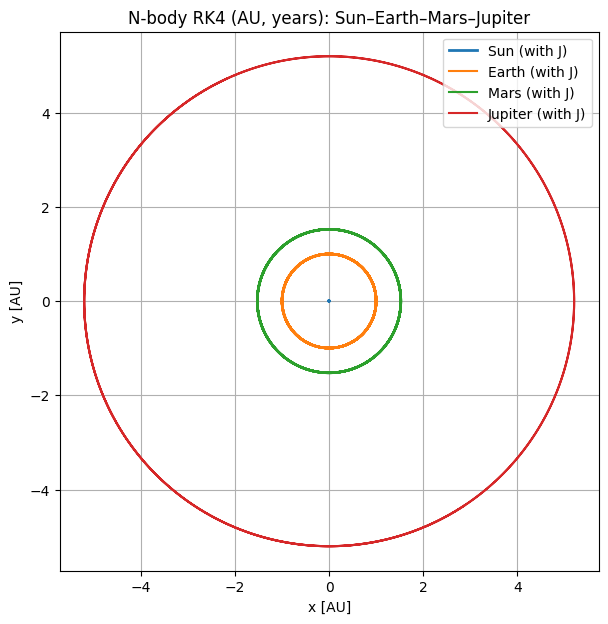

In [16]:

# Визуализация орбит (вокруг барицентра; Солнце тоже может немного двигаться)
fig = plt.figure(figsize=(7,7))
plt.plot(yJ[:,0,0], yJ[:,0,1], label="Sun (with J)", linewidth=2)
plt.plot(yJ[:,1,0], yJ[:,1,1], label="Earth (with J)")
plt.plot(yJ[:,2,0], yJ[:,2,1], label="Mars (with J)")
plt.plot(yJ[:,3,0], yJ[:,3,1], label="Jupiter (with J)")

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x [AU]"); plt.ylabel("y [AU]")
plt.grid(True); plt.legend()
plt.title("N-body RK4 (AU, years): Sun–Earth–Mars–Jupiter")
plt.show()


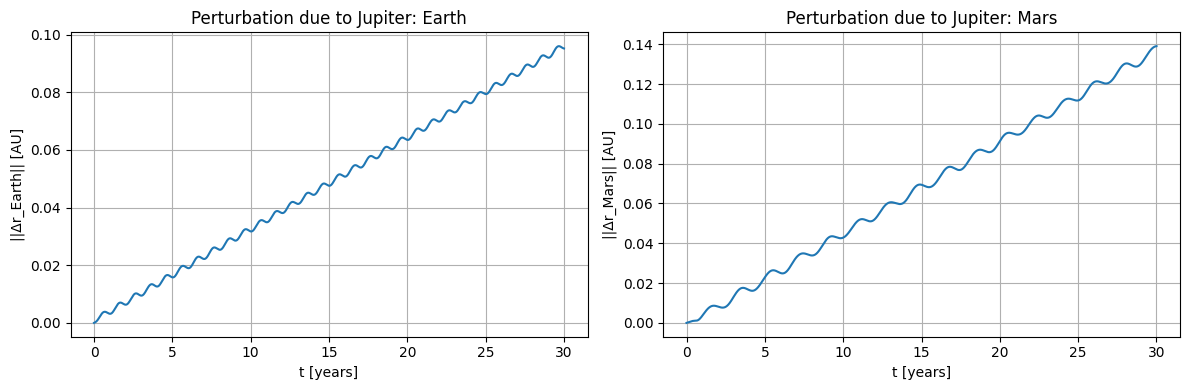

Max |Δr_Earth| over 30 years: 0.09597863633994798 AU
Max |Δr_Mars|  over 30 years: 0.139015001030037 AU


In [17]:

# Оценка влияния Юпитера: разница траекторий Земли и Марса (with J vs without J)
# Для сравнения приведём координаты в одну систему: используем барицентр (уже заложено скоростями),
# но ещё можно вычесть положение Солнца в каждом случае.

earth_J  = yJ[:,1,0:2] - yJ[:,0,0:2]
mars_J   = yJ[:,2,0:2] - yJ[:,0,0:2]

earth_No = yNoJ[:,1,0:2] - yNoJ[:,0,0:2]
mars_No  = yNoJ[:,2,0:2] - yNoJ[:,0,0:2]

dE = np.linalg.norm(earth_J - earth_No, axis=1)
dM = np.linalg.norm(mars_J  - mars_No,  axis=1)

fig = plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(tN, dE)
plt.xlabel("t [years]")
plt.ylabel("||Δr_Earth|| [AU]")
plt.grid(True)
plt.title("Perturbation due to Jupiter: Earth")

plt.subplot(1,2,2)
plt.plot(tN, dM)
plt.xlabel("t [years]")
plt.ylabel("||Δr_Mars|| [AU]")
plt.grid(True)
plt.title("Perturbation due to Jupiter: Mars")

plt.tight_layout()
plt.show()

print("Max |Δr_Earth| over", years, "years:", float(np.max(dE)), "AU")
print("Max |Δr_Mars|  over", years, "years:", float(np.max(dM)), "AU")
